# Denovo docking run — input preparation & checks

Both inputs to a GFN denovo docking run get prepared and sanity-checked here, with **LRRK2 /
8TZC** as the worked example. This notebook is **diagnostic only — it changes no config files**;
it tells you what to put in `denovo_lrrk2.yml`, and Part 3 shows how.

1. **Protein / docking box.** Confirm the Uni-Dock search box (`denovo_lrrk2.yml`) actually sits on
   the binding site of the receptor that gets docked (`lrrk2.pdbqt`). The primary check needs only
   the **RCSB PDB + its co-crystal reference ligand** (MLI-2). A second structure from a different
   prep pipeline (BIOVIA `8TZC.pdb`) is *optional*: if you have one, the cross-frame cells diagnose a
   coordinate-frame mismatch; if you set `BIOVIA_PATH = None`, they auto-skip.
2. **Ligand seed.** This repo can start every trajectory from a fixed seed molecule and *freeze* part
   of it (`initial_scaffold` + `allowed_growth_atoms`/`frozen_atoms`). Those atoms are addressed by
   **0-based RDKit index**, so we draw the seed in 2D with each atom's index annotated — making it
   unambiguous which atoms you're freezing — then validate the choice with the repo's own builder.
3. **Config guide.** A markdown recipe translating your Part 1 box and Part 2 frozen-core choices into
   `denovo_lrrk2.yml`, with a paste-ready example and the launch command.

> `8TZC_RCSB.pdb` also carries **GDP** (in the GTPase / ROC domain, far from the kinase site) and a
> water; we filter HETATM to `A1N` so the reference ligand tracks the MLI-2 inhibitor, not GDP.

Run top-to-bottom. Requires `py3Dmol` and `rdkit` (both in the `agfn` env).
**Import order matters:** `py3Dmol` is imported *before* `rdkit.Chem.Draw` in the setup cell — the
reverse order segfaults the kernel. Keep it that way.

In [1]:
# ----- Parameters (edit these) -----

# --- Part 1: protein / docking box ---
CONFIG_PATH     = "./src/config/denovo_lrrk2.yml"   # source of the configured docking box
DOCK_FRAME_PATH = "./data/docking/lrrk2.pdbqt"      # receptor actually used for docking (RCSB frame)
RCSB_PATH       = "./data/docking/8TZC_RCSB.pdb"    # official RCSB structure (same frame) + MLI-2 ligand
LIGAND_RESN     = "A1N"                             # co-crystal inhibitor MLI-2 (HETATM residue name)
# Optional second structure from a different prep pipeline, used ONLY for the cross-frame diagnostic.
# Set to None to skip that diagnostic and validate with the RCSB PDB + reference ligand alone.
BIOVIA_PATH     = "./data/docking/8TZC.pdb"         # BIOVIA / Discovery Studio prep (different frame); or None
VIEW_W, VIEW_H  = 620, 460

# --- Part 2: ligand seed / frozen-core ---
# The molecule you intend to seed `initial_scaffold` with. Defaults to the MLI-2 inhibitor (PDB
# chem-comp A1N) so this example is self-contained; if your config already sets
# initial_scaffold/seed_smiles, the cell below prefers that. Atoms are addressed by 0-based RDKit
# index (the order they appear here), exactly as `allowed_growth_atoms`/`frozen_atoms` expect.
SEED_SMILES = "C[C@H]1CN(C[C@@H](C)O1)c2cc(ncn2)c3n[nH]c4ccc(OC5(C)CC5)cc34"  # MLI-2 (A1N)

# Preview a frozen/growth partition. Set EXACTLY ONE of these (the other stays None); leave both
# None to freeze the whole core while letting new atoms attach at any seed atom. Indices are the
# 0-based labels shown on the 2D drawing in Part 2.
ALLOWED_GROWTH_ATOMS = None    # e.g. [0, 3]  -> only these seed atoms may grow; all others frozen
FROZEN_ATOMS         = None    # e.g. [10, 11] -> these are frozen; every other seed atom may grow

In [2]:
import os, sys
from pathlib import Path

# chdir to repo root so the relative paths above resolve (mirrors notebooks/visualize.ipynb).
_here = Path.cwd()
for cand in [_here, *_here.parents]:
    cfg = cand / "src" / "config"
    if (cfg / "denovo_lrrk2.yml").exists() or (cfg / "denovo.yml").exists():
        os.chdir(cand); break
REPO_ROOT = Path.cwd()
print("repo root:", REPO_ROOT)

import numpy as np
import yaml
from easydict import EasyDict

# IMPORTANT: import py3Dmol BEFORE anything pulls in rdkit.Chem.Draw (Part 2). py3Dmol and rdkit's
# 2D drawing link against conflicting C++ libraries; whichever loads second corrupts the other, and
# loading Draw first segfaults the kernel. Importing py3Dmol here, up front, fixes the order for the
# whole notebook. (rdkit.Chem core is safe to import in any order; only Chem.Draw is order-sensitive.)
import py3Dmol
print("py3Dmol", py3Dmol.__version__)

repo root: /home/aid/dkoh/third_party/AGFN
py3Dmol 2.5.4


# Part 1 — Protein / docking-box check

Is the configured Uni-Dock box centered on the binding site of the receptor we actually dock
(`lrrk2.pdbqt`)? The cells below read the box from the config exactly as the training backend does,
then check it two ways:

- **Primary (always runs):** does the box enclose the **reference co-crystal ligand** (MLI-2) in the
  RCSB structure, and does it sit on the receptor? Needs only `DOCK_FRAME_PATH` + `RCSB_PATH`.
- **Optional (needs `BIOVIA_PATH`):** if your box looks off, a second structure from a different prep
  pipeline lets us Kabsch-superpose the frames and detect a coordinate-frame mismatch. Auto-skips when
  `BIOVIA_PATH = None`.

In [3]:
# Read the configured box exactly the way the training backend does
# (see notebooks/visualize.ipynb and src/apps/docking/unidock.py).
hps  = EasyDict(yaml.safe_load(open(CONFIG_PATH))).finetuning
grid = dict(hps.target_grid[hps.target_name])
center = np.array([grid["center_x"], grid["center_y"], grid["center_z"]], float)
size   = np.array([grid["size_x"],   grid["size_y"],   grid["size_z"]],   float)

print(f"target             : {hps.target_name}")
print(f"receptor (docking) : {grid['receptor']}")
print(f"box center         : {center}")
print(f"box size (A)       : {size}")
print(f"box min corner     : {np.round(center - size / 2, 2)}")
print(f"box max corner     : {np.round(center + size / 2, 2)}")

target             : lrrk2
receptor (docking) : ./data/docking/lrrk2.pdbqt
box center         : [185.7 178.1 144.7]
box size (A)       : [22.032 22.032 22.032]
box min corner     : [174.68 167.08 133.68]
box max corner     : [196.72 189.12 155.72]


In [4]:
def read_atoms(path, records=("ATOM",)):
    """Parse fixed-column PDB/PDBQT coordinates. Returns (coords[N,3], keys[N]) where each
    key is (chain, resSeq, atom_name) so atoms can be matched across files."""
    coords, keys = [], []
    for ln in open(path):
        if ln[:6].strip() in records:
            try:
                xyz = (float(ln[30:38]), float(ln[38:46]), float(ln[46:54]))
            except ValueError:
                continue
            coords.append(xyz)
            keys.append((ln[21], ln[22:27].strip(), ln[12:16].strip()))
    return np.array(coords), keys


def read_ligand(path, resn):
    """Coordinates of a single HETATM residue (e.g. the co-crystal inhibitor)."""
    coords = []
    for ln in open(path):
        if ln[:6].strip() == "HETATM" and ln[17:20].strip() == resn:
            try:
                coords.append((float(ln[30:38]), float(ln[38:46]), float(ln[46:54])))
            except ValueError:
                pass
    return np.array(coords)


def box_diag(coords, c, s):
    """How a box sits on an atom cloud: (#inside, fraction_inside, nearest_atom_distance)."""
    lo, hi = c - s / 2, c + s / 2
    inside = ((coords >= lo) & (coords <= hi)).all(1)
    nearest = float(np.linalg.norm(coords - c, axis=1).min())
    return int(inside.sum()), float(inside.mean()), nearest


def kabsch(P, Q):
    """Optimal rigid transform mapping P onto Q. Returns (R, t, rmsd); Q ~= P @ R.T + t."""
    Pc, Qc = P - P.mean(0), Q - Q.mean(0)
    U, S, Vt = np.linalg.svd(Pc.T @ Qc)
    d = np.sign(np.linalg.det(Vt.T @ U.T))
    R = Vt.T @ np.diag([1.0, 1.0, d]) @ U.T
    t = Q.mean(0) - R @ P.mean(0)
    rmsd = float(np.sqrt((((R @ P.T).T + t - Q) ** 2).sum(1).mean()))
    return R, t, rmsd


def iou(c1, c2, s):
    """IoU of two equal-size axis-aligned boxes. (Box B's rotation is dropped for this
    glyph-level metric; its center is exact.)"""
    lo = np.maximum(c1 - s / 2, c2 - s / 2)
    hi = np.minimum(c1 + s / 2, c2 + s / 2)
    inter = float(np.prod(np.clip(hi - lo, 0, None)))
    vol = float(np.prod(s))
    return inter / (2 * vol - inter)

In [5]:
# Primary check (no BIOVIA needed): does the configured box sit on the receptor and enclose the
# reference co-crystal ligand? Everything here is in the docking (RCSB) frame.
receptor, _ = read_atoms(DOCK_FRAME_PATH)
lig         = read_ligand(RCSB_PATH, LIGAND_RESN)
if len(lig) == 0:
    raise ValueError(f"No HETATM residue {LIGAND_RESN!r} found in {RCSB_PATH}; "
                     f"set LIGAND_RESN to the co-crystal ligand's residue name.")
lig_center  = lig.mean(0)

box_A = center        # the configured box, as written in the config (what docking uses)
box_C = lig_center    # a box re-centered on the reference ligand

rec_in, rec_frac, rec_near = box_diag(receptor, box_A, size)   # receptor atoms inside the box
lig_in, lig_frac, _        = box_diag(lig,      box_A, size)   # ligand atoms inside the box
center_to_lig = float(np.linalg.norm(box_A - lig_center))

print(f"target              : {hps.target_name}")
print(f"configured center   : {np.round(box_A, 2)}   size {np.round(size, 2)}")
print()
print(f"receptor ({DOCK_FRAME_PATH.split('/')[-1]}): {len(receptor)} atoms")
print(f"  atoms inside box  : {rec_in} ({100 * rec_frac:.1f}%)   nearest atom -> center: {rec_near:.1f} A")
print(f"reference ligand {LIGAND_RESN} (MLI-2): {len(lig)} atoms, centroid {np.round(lig_center, 1)}")
print(f"  atoms inside box  : {lig_in}/{len(lig)} ({100 * lig_frac:.0f}% enclosed)")
print(f"  center -> ligand centroid: {center_to_lig:.1f} A")
print(f"  IoU(configured box, ligand-centered box): {iou(box_A, box_C, size):.2f}")
print()

# Verdict: a good box surrounds most of the co-crystal ligand and is centered near it.
ok = lig_frac >= 0.8 and center_to_lig <= float(size.min()) / 2
if ok:
    print("VERDICT: OK -- the configured box encloses the reference ligand and is centered on it.")
else:
    print("VERDICT: CHECK -- the configured box does NOT enclose the reference ligand well.")
    print("  Either the box center/size is off, or the coords are in the wrong frame.")
    print("  Try the ligand-centered box below, or run the optional BIOVIA cross-frame diagnostic.")
print()
print("--- paste-ready ligand-centered box (size unchanged) ---")
print(f"  center_x: {lig_center[0]:.4f}  center_y: {lig_center[1]:.4f}  center_z: {lig_center[2]:.4f}")

target              : lrrk2
configured center   : [185.7 178.1 144.7]   size [22.03 22.03 22.03]

receptor (lrrk2.pdbqt): 15974 atoms
  atoms inside box  : 800 (5.0%)   nearest atom -> center: 2.6 A
reference ligand A1N (MLI-2): 28 atoms, centroid [185.3 178.4 144.2]
  atoms inside box  : 28/28 (100% enclosed)
  center -> ligand centroid: 0.7 A
  IoU(configured box, ligand-centered box): 0.90

VERDICT: OK -- the configured box encloses the reference ligand and is centered on it.

--- paste-ready ligand-centered box (size unchanged) ---
  center_x: 185.2618  center_y: 178.3955  center_z: 144.2253


In [6]:
def view_structure(path, fmt, boxes=(), ligand_resn=None,
                   bg="0x0e1116", zoom_out=1.0, w=VIEW_W, h=VIEW_H):
    """Cartoon view of a receptor with one or more docking boxes overlaid.
    boxes: iterable of (center, size, color). Optional ligand drawn as green sticks.
    bg: py3Dmol background color (dark by default); zoom_out < 1 pulls the camera back
    so boxes that sit off the protein stay in frame."""
    txt = open(path).read()
    v = py3Dmol.view(width=w, height=h)
    v.setBackgroundColor(bg)
    v.addModel(txt, fmt)
    v.setStyle({"cartoon": {"color": "spectrum"}})
    if ligand_resn:
        v.addStyle({"resn": ligand_resn},
                   {"stick": {"colorscheme": "greenCarbon", "radius": 0.25}})
    for c, s, color in boxes:
        v.addBox({"center": {"x": float(c[0]), "y": float(c[1]), "z": float(c[2])},
                  "dimensions": {"w": float(s[0]), "h": float(s[1]), "d": float(s[2])},
                  "color": color, "wireframe": True})
    v.zoomTo()
    if zoom_out != 1.0:
        v.zoom(zoom_out)
    return v

## Box overlays — does the box surround the binding site?

Magenta wireframe = the box from `denovo_lrrk2.yml`. A correctly configured box sits on the receptor
and wraps the green MLI-2 ligand sticks; a misconfigured one floats off in empty space.

In [7]:
# Docking receptor (lrrk2.pdbqt) + configured box.
# A correct box sits on the protein; a frame-mismatched one floats off in empty space.
view_structure(DOCK_FRAME_PATH, "pdbqt", boxes=[(center, size, "magenta")]).show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [8]:
# 8TZC_RCSB.pdb (same frame as the pdbqt) + configured box + MLI-2 (green sticks).
# The inhibitor marks the true pocket: a correct box should wrap the green sticks.
view_structure(RCSB_PATH, "pdb",
               boxes=[(center, size, "magenta")], ligand_resn=LIGAND_RESN).show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Optional — cross-frame diagnostic (needs `BIOVIA_PATH`)

If the primary check flagged the box as off, the usual culprit is a **coordinate-frame mismatch**:
the box coordinates were picked in one structure's frame (e.g. a BIOVIA / Discovery Studio prep) but
the docking runs against a receptor in a different frame (RCSB). With a second structure of the same
protein we can superpose the two frames (Kabsch fit on matched atoms — they share residue numbering,
so no sequence alignment is needed) and map the configured box into the docking frame to confirm the
*intended* pocket and recover the corrected center.

**These cells auto-skip when `BIOVIA_PATH = None`.** They are a diagnostic, not part of the routine
check — a box that already passed the primary check needs none of this.

In [9]:
# 8TZC.pdb (BIOVIA frame) + configured box. If the box was picked in this frame, it sits squarely on
# a pocket here even when it floats off the RCSB receptor above -- the tell-tale of a frame mismatch.
if BIOVIA_PATH and Path(BIOVIA_PATH).exists():
    view_structure(BIOVIA_PATH, "pdb", boxes=[(center, size, "magenta")]).show()
else:
    print("BIOVIA_PATH not set / not found -> skipping cross-frame diagnostic.")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Superpose `8TZC.pdb` (BIOVIA) onto `lrrk2.pdbqt` (RCSB) by matching atoms on
`(chain, resSeq, atom_name)`, then compare three same-size boxes against the MLI-2 pocket (box **C**,
the ground truth): **A** the configured center as-written, **B** that center reinterpreted as a
BIOVIA-frame point and mapped into the docking frame. Whichever of A or B lands on box C is the
center that's truly in the docking frame — if it's **A**, the box is already correct and needs no fix.

In [10]:
box_B = None   # frame-corrected configured box; stays None when no BIOVIA frame is available
if BIOVIA_PATH and Path(BIOVIA_PATH).exists():
    # Match atoms BIOVIA (8TZC.pdb) -> RCSB (lrrk2.pdbqt) and superpose.
    B_xyz, B_keys = read_atoms(BIOVIA_PATH)
    R_xyz, R_keys = read_atoms(DOCK_FRAME_PATH)
    r_index = {k: i for i, k in enumerate(R_keys)}
    pairs = [(B_xyz[i], R_xyz[r_index[k]]) for i, k in enumerate(B_keys) if k in r_index]
    P = np.array([p for p, _ in pairs])
    Q = np.array([q for _, q in pairs])
    Rot, trans, rmsd = kabsch(P, Q)
    verdict = "same protein" if rmsd < 2 else "CHECK -- high RMSD"
    print(f"superposition BIOVIA -> RCSB: {len(P)} atoms matched, RMSD {rmsd:.3f} A ({verdict})")

    # Box B = the configured center reinterpreted as a BIOVIA-frame point and mapped into the docking
    # frame. The co-crystal ligand (box C) is the ground-truth pocket: whichever of A (as-written) or
    # B (frame-corrected) lands on C is the center that is actually in the docking frame.
    box_B = Rot @ center + trans
    print()
    print(f"{'box':<38}{'center (RCSB frame)':<24}{'in-box':>8}{'->lig':>8}")
    for name, c in [("A as-written (docking uses this)", box_A),
                    ("B frame-corrected (A as BIOVIA)",  box_B),
                    ("C ligand-defined (MLI-2 centroid)", box_C)]:
        n_in, _, _ = box_diag(receptor, c, size)
        print(f"{name:<38}{str(np.round(c, 1)):<24}{n_in:>8}{np.linalg.norm(c - box_C):>7.1f}A")
    print()
    if np.linalg.norm(box_A - box_C) <= np.linalg.norm(box_B - box_C):
        print("=> box A (as-written) is closest to the MLI-2 pocket: the configured box is ALREADY in")
        print("   the docking frame -- no fix needed (box B is just the wrong-frame image here).")
    else:
        print("=> box B is closest to the MLI-2 pocket: the configured coords are in the BIOVIA frame.")
        print("   Replace center_x/y/z with box B below (size unchanged).")
    print()
    print("--- paste-ready centers (size unchanged) ---")
    for nm, c in [("frame-corrected (box B)", box_B), ("MLI-2 site (box C)", box_C)]:
        print(f"  {nm:<26} center_x: {c[0]:.4f}  center_y: {c[1]:.4f}  center_z: {c[2]:.4f}")
else:
    print("BIOVIA_PATH not set / not found -> skipping cross-frame superposition.")

superposition BIOVIA -> RCSB: 10104 atoms matched, RMSD 0.828 A (same protein)

box                                   center (RCSB frame)       in-box   ->lig
A as-written (docking uses this)      [185.7 178.1 144.7]          800    0.7A
B frame-corrected (A as BIOVIA)       [227.8 131.2 160.7]            0   65.7A
C ligand-defined (MLI-2 centroid)     [185.3 178.4 144.2]          766    0.0A

=> box A (as-written) is closest to the MLI-2 pocket: the configured box is ALREADY in
   the docking frame -- no fix needed (box B is just the wrong-frame image here).

--- paste-ready centers (size unchanged) ---
  frame-corrected (box B)    center_x: 227.8337  center_y: 131.2101  center_z: 160.6925
  MLI-2 site (box C)         center_x: 185.2618  center_y: 178.3955  center_z: 144.2253


In [11]:
# Final superimpose view on the RCSB structure (= docking frame, and it carries MLI-2). Draws:
#   red    = box A, configured coords as written in denovo_lrrk2.yml
#   cyan   = box B, box A reinterpreted as a BIOVIA-frame point and mapped into the docking frame
#   orange = box C, the MLI-2 ligand center (ground-truth pocket)
# Correct box: A and C coincide on the pocket and B flies off. Frame bug: A flies off, B lands on C.
if BIOVIA_PATH and Path(BIOVIA_PATH).exists() and box_B is not None:
    print("box colors:  red = configured (A)    cyan = frame-corrected (B)    "
          "orange = MLI-2 ligand box (C)    green sticks = MLI-2")
    view_structure(RCSB_PATH, "pdb",
                   boxes=[(box_A, size, "red"), (box_B, size, "cyan"), (box_C, size, "orange")],
                   ligand_resn=LIGAND_RESN, zoom_out=0.8).show()
else:
    print("BIOVIA_PATH not set / not found -> skipping 3-box comparison view.")

box colors:  red = configured (A)    cyan = frame-corrected (B)    orange = MLI-2 ligand box (C)    green sticks = MLI-2


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### Part 1 takeaway

- The **primary check** verdict is the one to trust: a good box encloses the reference ligand
  (`% enclosed` near 100) and is centered within a few Å of its centroid. If it says `CHECK`, fix the
  box — paste the ligand-centered center it prints into `target_grid.<target>` (Part 3), keeping
  `size` unchanged.
- The **cross-frame diagnostic** only matters when the primary check fails: it superposes a second
  structure and reports whether the configured center (box **A**) or its frame-corrected image (box
  **B**) lands on the MLI-2 pocket. If A is off and B lands on it, the coords were authored in the
  wrong frame — use box **B**'s center.
- Historical note for this example: the LRRK2 box was originally authored in the BIOVIA frame (~41 Å
  off the RCSB receptor) and has since been corrected in `denovo_lrrk2.yml`, so the primary check now
  passes and the diagnostic confirms box **A** is already in the docking frame. The cells stay
  verdict-driven so they remain useful for any target you point them at.

# Part 2 — Ligand seed / frozen-atom preparation

This repo can start **every** GFN trajectory from a fixed seed molecule and hold part of it immutable
(`initial_scaffold` in the config). The whole seed is a frozen *core* — its atoms, bonds, and atom
attributes never change — and you additionally choose **growth sites**: the subset of seed atoms at
which new atoms may attach. You declare them by atom index, two equivalent ways:

- `allowed_growth_atoms: [...]` — only these seed atoms may grow; every other seed atom is sealed.
- `frozen_atoms: [...]` — these atoms are sealed; every *other* seed atom may grow.

**The indices are 0-based RDKit parse order** — i.e. `atom.GetIdx()` on `Chem.MolFromSmiles(seed)`.
The repo's `build_frozen_seed_graph` asserts the seed's graph nodes are exactly `0..N-1` in that
order, so the numbers you read off the 2D drawing below are precisely the numbers the config consumes.
Hydrogens are implicit and are **not** indexed — you only ever address heavy atoms.

In [12]:
# Resolve the seed molecule: prefer the config's initial_scaffold/seed_smiles if set, else the
# SEED_SMILES parameter (default MLI-2). rdkit.Chem core is safe to import in any order; only
# rdkit.Chem.Draw is order-sensitive (imported in the next cell, after py3Dmol).
from rdkit import Chem

cfg_seed   = hps.get('initial_scaffold') or hps.get('seed_smiles')
seed_smiles = cfg_seed or SEED_SMILES
seed_src   = "config (initial_scaffold/seed_smiles)" if cfg_seed else "SEED_SMILES parameter"

mol = Chem.MolFromSmiles(seed_smiles)
if mol is None:
    raise ValueError(f"seed SMILES did not parse: {seed_smiles!r}")

print(f"seed source : {seed_src}")
print(f"seed SMILES : {seed_smiles}")
print(f"heavy atoms : {mol.GetNumAtoms()}  (hydrogens implicit, not indexed)")
print()
print("index : symbol  (these are the numbers you put in allowed_growth_atoms / frozen_atoms)")
print("  " + ",  ".join(f"{a.GetIdx()}:{a.GetSymbol()}" for a in mol.GetAtoms()))

seed source : SEED_SMILES parameter
seed SMILES : C[C@H]1CN(C[C@@H](C)O1)c2cc(ncn2)c3n[nH]c4ccc(OC5(C)CC5)cc34
heavy atoms : 28  (hydrogens implicit, not indexed)

index : symbol  (these are the numbers you put in allowed_growth_atoms / frozen_atoms)
  0:C,  1:C,  2:C,  3:N,  4:C,  5:C,  6:C,  7:O,  8:C,  9:C,  10:C,  11:N,  12:C,  13:N,  14:C,  15:N,  16:N,  17:C,  18:C,  19:C,  20:C,  21:O,  22:C,  23:C,  24:C,  25:C,  26:C,  27:C


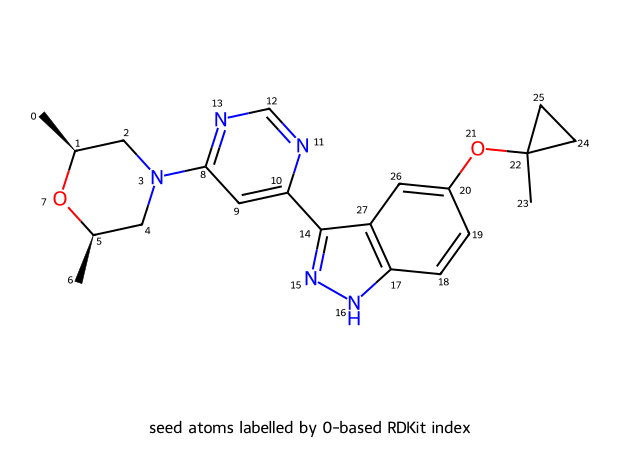

In [13]:
# 2D depiction with each atom's 0-based index annotated. py3Dmol was imported FIRST in the setup
# cell; importing rdkit.Chem.Draw before it segfaults the kernel, so keep this import here (or later).
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem import rdDepictor
from IPython.display import SVG


def draw_seed(mol, highlight=None, legend="", size=(620, 460)):
    """SVG of `mol` with each atom labelled by its 0-based RDKit index (atomNote).
    `highlight`: optional {atom_idx: (r, g, b)} to color a subset of atoms."""
    m = Chem.Mol(mol)                       # copy so we don't mutate the shared `mol`
    rdDepictor.Compute2DCoords(m)
    for a in m.GetAtoms():
        a.SetProp("atomNote", str(a.GetIdx()))
    hl  = list(highlight) if highlight else []
    hlc = highlight if isinstance(highlight, dict) else None
    d = rdMolDraw2D.MolDraw2DSVG(*size)
    rdMolDraw2D.PrepareAndDrawMolecule(d, m, highlightAtoms=hl,
                                       highlightAtomColors=hlc, legend=legend)
    d.FinishDrawing()
    return SVG(d.GetDrawingText())


# Plain index map: read off which atoms you want to freeze / grow from.
draw_seed(mol, legend="seed atoms labelled by 0-based RDKit index")

seed core (all atoms immutable): 28 atoms
growth sites (green, new atoms may attach): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
sealed-only  (red, no attachment)         : []


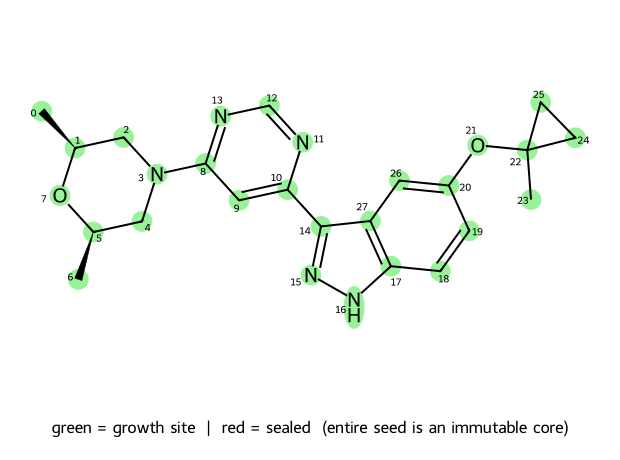

In [14]:
# Preview the partition implied by ALLOWED_GROWTH_ATOMS / FROZEN_ATOMS (set in the Parameters cell),
# computed exactly the way build_frozen_seed_graph does. Every seed atom is immutable; "growth sites"
# are the subset where new atoms may attach.
n = mol.GetNumAtoms()


def resolve_growth(n, allowed, frozen):
    if allowed is not None and frozen is not None:
        raise ValueError("Set only ONE of ALLOWED_GROWTH_ATOMS / FROZEN_ATOMS (leave the other None).")
    if allowed is not None:
        return set(allowed)
    if frozen is not None:
        return set(range(n)) - set(frozen)
    return set(range(n))            # neither set -> whole core frozen, every atom is a growth site


growth      = resolve_growth(n, ALLOWED_GROWTH_ATOMS, FROZEN_ATOMS)
sealed_only = set(range(n)) - growth
colors = {**{i: (1.00, 0.60, 0.60) for i in sealed_only},   # red  = sealed (no new attachment)
          **{i: (0.60, 0.95, 0.60) for i in growth}}         # green = growth site

print(f"seed core (all atoms immutable): {n} atoms")
print(f"growth sites (green, new atoms may attach): {sorted(growth)}")
print(f"sealed-only  (red, no attachment)         : {sorted(sealed_only)}")
draw_seed(mol, highlight=colors,
          legend="green = growth site  |  red = sealed  (entire seed is an immutable core)")

In [15]:
# Authoritative check: build the seed graph with the repo's OWN builder, exactly as the trainer does
# (src/iterators/samp_iter_finetune.py). This validates atom types against the model's atom set,
# checks index ranges, enforces "at least one growth site", and prints the same frozen_seed_size /
# frozen_growth_sites the training run will use. A red error here = a config that would fail at launch.
sys.path.insert(0, str(REPO_ROOT / "src"))
from gflownet.envs.mol_building_env import MolBuildingEnvContext, build_frozen_seed_graph

ctx = MolBuildingEnvContext(atoms=hps.atoms, max_nodes=hps.get("max_nodes"))
try:
    g = build_frozen_seed_graph(ctx, seed_smiles,
                                allowed_growth_atoms=ALLOWED_GROWTH_ATOMS,
                                frozen_atoms=FROZEN_ATOMS)
    seed_n = g.graph["frozen_seed_size"]
    print(f"OK -- this spec is valid and trainable.")
    print(f"  frozen_seed_size    = {seed_n}")
    print(f"  frozen_growth_sites = {sorted(g.graph['frozen_growth_sites'])}")
    if ctx.max_nodes:
        print(f"  room to grow        = max_nodes({ctx.max_nodes}) - seed({seed_n}) "
              f"= {ctx.max_nodes - seed_n} atoms")
    print()
    print("Copy SEED_SMILES + your index list into denovo_lrrk2.yml as shown in Part 3.")
except Exception as e:
    print(f"INVALID -- {type(e).__name__}: {e}")
    print("Fix SEED_SMILES or the index list (Parameters cell) before training.")

molbuildingenv.py c import error
OK -- this spec is valid and trainable.
  frozen_seed_size    = 28
  frozen_growth_sites = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
  room to grow        = max_nodes(45) - seed(28) = 17 atoms

Copy SEED_SMILES + your index list into denovo_lrrk2.yml as shown in Part 3.


/home/aid/dkoh/third_party/AGFN/src/gflownet/envs/mol_building_env.py:27: UserWarning: Could not import mol_graph_to_Data, Graph, GraphDef from _C, using pure python implementation
  warnings.warn("Could not import mol_graph_to_Data, Graph, GraphDef from _C, using pure python implementation")


# Part 3 — Configuring `denovo_lrrk2.yml`

Translate your Part 1 box and Part 2 seed choices into the config. **Everything lives under the
top-level `finetuning:` key** (loaded by `src/apps/docking/denovo/denovo_driver.py`). This notebook
writes nothing — edit the YAML yourself.

### Docking box (Part 1)
Select the target with `target_name`, and define its box under `target_grid.<target_name>`:

| field | meaning |
|---|---|
| `receptor` | path to the `.pdbqt` that gets docked (`./data/docking/lrrk2.pdbqt`) |
| `center_x/y/z` | box center, **Å, in the receptor's own coordinate frame** |
| `size_x/y/z` | box edge lengths, Å |

If Part 1's primary check said `CHECK`, paste the **ligand-centered center** it printed (or box **B**
from the cross-frame diagnostic) into `center_x/y/z`, leaving `size_*` unchanged.

### Seed + frozen atoms (Part 2)
Set `initial_scaffold` to your seed SMILES, then choose **exactly one** growth spec (or neither):

| you set | effect |
|---|---|
| `allowed_growth_atoms: [i, j, …]` | only atoms *i, j, …* may grow; all other seed atoms sealed |
| `frozen_atoms: [i, j, …]` | atoms *i, j, …* sealed; every other seed atom may grow |
| neither | whole core frozen, but new atoms may attach at **any** seed atom |

Indices are the **0-based numbers from the Part 2 drawing**. Setting both raises an error; sealing
every atom raises an error.

**Gotchas (all checked by the Part 2 validation cell):**
- When `initial_scaffold` is set, `seed_smiles` / `seed_scaffold` are **ignored**.
- Frozen-core runs **online-only** — the trainer auto-forces `offline_data: False` and prints
  `[frozen-core] forcing ONLINE-ONLY mode` at startup (offline dataset molecules can't preserve the core).
- Seed atoms must be within the model's atom set `atoms: ['Br','C','Cl','F','I','N','O','S']`.
- Seed size must be `< max_nodes` (here 45) to leave room to grow.

### Paste-ready example (LRRK2 + MLI-2 seed)
```yaml
finetuning:
  target_name: "lrrk2"
  target_grid:
    lrrk2:
      receptor: "./data/docking/lrrk2.pdbqt"
      center_x: 185.7        # corrected pocket center (Part 1); was a BIOVIA-frame value
      center_y: 178.1
      center_z: 144.7
      size_x: 22.032
      size_y: 22.032
      size_z: 22.032

  # Frozen-core seed: start from MLI-2 and grow only at the atoms you chose in Part 2.
  initial_scaffold: "C[C@H]1CN(C[C@@H](C)O1)c2cc(ncn2)c3n[nH]c4ccc(OC5(C)CC5)cc34"
  allowed_growth_atoms: [16]   # <-- replace with the green indices from your Part 2 drawing
  frozen_atoms: null           # leave null when using allowed_growth_atoms
  # offline_data is forced to False automatically when initial_scaffold is set
```

### Launch
```bash
conda run -n agfn python ./src/apps/docking/denovo/denovo_driver.py ./src/config/denovo_lrrk2.yml
```